<a href="https://colab.research.google.com/github/GustavoFA/IA368/blob/main/bert.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA368-HH

## BERT - Bidirectional Encoder Representations from Transformers

Gustavo Freitas Alves

236249

---

In [ ]:
!pip install torchinfo -q

In [ ]:
import os

import re

import time

import requests

import time
import math

import random

import numpy as np

from tqdm import tqdm

import torch
import torchinfo
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import BertTokenizer, BertModel

from sklearn.model_selection import train_test_split

from matplotlib import pyplot as plt

---
### Definindo modelo pré-treinado do BERT

Como o dataset que utilizo está um português (PT-BR), logo irei trabalhar com um modelo pré-treinado no mesmo idioma, o BERTimbau. Utilizarei o Base size.

In [ ]:
# # Modelo em PT-BR - interessante para os texto que estamos utilizando
pre_train_model = 'neuralmind/bert-base-portuguese-cased'

# Modelo pequeno do BERT - ótimo para verificação geral
# pre_train_model = 'prajjwal1/bert-tiny'

---
### Dados


Clonando repositório com o texto a ser utilizado. Obras de Machado de Assis.

In [ ]:
# caminho para o arquivo
DATA_PATH_PT = r'projetomachado/textonormalizado1000.txt'

In [ ]:
!git clone -q https://github.com/ethelbeluzzi/projetomachado

#### Analisando os dados do texto

In [ ]:
characters = None
lines = None

# obtendo os caracteres do texto
with open(DATA_PATH_PT, 'r') as text:
  # characters = text.read()
  lines = text.readlines()
# verificando número de caracteres no texto (apenas para entendimento)
if characters is not None: print(f'Número de caracteres: {len(characters)}')
# verificiando número de linhas
if lines is not None: print(f'Número de linhas: {len(lines)}')

Número de linhas: 306409


In [ ]:
if lines:
  n = random.randint(0,len(lines))
  print(f'[{n}] - {lines[n]}')

[179654] - jo da ode.



Filtragem do texto

In [ ]:
# limpeza dos dados - remover \n e espaços
# Logo, estaremos mantendo palavras (incluindo acentos), pontuações, números e símbolos
# Irei manter diferenças de Maiúsculas e Minúsculas
# \w+ = caracteres alfanuméricos e underscore (uma ou mais)
# ^\w\s = pontuações e símbolos
# UNICODE -> permite letras com acentuações (além de letras gregas e dentre outras)
filter_lines = [" ".join(re.findall(r'\w+|[^\w\s]', line, flags=re.UNICODE)) for line in lines]

In [ ]:
print(f'[{n}] - {filter_lines[n]}')

[179654] - jo da ode .


#### Separando os conjuntos de treino e validação

Utilizando a lib do Sklearn (train_test_split) para fazer a divisão do dataset

In [ ]:
%%time
# dimensão para validação do código (para testes rápidos)
# data_ratio = 0.05
# dimensão completa (usada no treinamento final)
data_ratio = 1
# Proporção dos dados para validação (20%)
val_ratio = 0.2
# Separação dos conjunto de treino e validação
lines_train, lines_val = train_test_split(
    filter_lines[:int(data_ratio * len(filter_lines))],
    test_size=val_ratio,
    random_state=18, # divisão deterministica
)

CPU times: user 118 ms, sys: 9.71 ms, total: 128 ms
Wall time: 282 ms


Contabilizando número de linhas para treino e validação

In [ ]:
print(f'Número de linhas de treino: {len(lines_train)}')
print(f'Número de linhas de validação: {len(lines_val)}')

Número de linhas de treino: 245127
Número de linhas de validação: 61282


---
### Tokenizador

Carrego o tokenizador do modelo pré-treinado do BERT. Como mencionado anteriormente estou utilizando o BERTimbau.

In [ ]:
tokenizer = BertTokenizer.from_pretrained(pre_train_model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/43.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/647 [00:00<?, ?B/s]

Tamanho do vocabulário do tokenizador

In [ ]:
VOCAB_SIZE = tokenizer.vocab_size
VOCAB_SIZE

29794

#### Verificando o funcionamento do tokenizador (apenas para entendimento)

In [ ]:
phrase = "The quick brown fox jumps over the lazy dog, showcasing the tokenizer's ability to handle diverse words and punctuation."

In [ ]:
tok = tokenizer(phrase)

In [ ]:
tok

{'input_ids': [101, 1996, 4248, 2829, 4419, 14523, 2058, 1996, 13971, 3899, 1010, 27696, 1996, 19204, 17629, 1005, 1055, 3754, 2000, 5047, 7578, 2616, 1998, 26136, 6593, 14505, 1012, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
len(tok['input_ids']), len(tok['token_type_ids']), len(tok['attention_mask'])

(28, 28, 28)

In [ ]:
tokenizer.tokenize(phrase)

['the',
 'quick',
 'brown',
 'fox',
 'jumps',
 'over',
 'the',
 'lazy',
 'dog',
 ',',
 'showcasing',
 'the',
 'token',
 '##izer',
 "'",
 's',
 'ability',
 'to',
 'handle',
 'diverse',
 'words',
 'and',
 'pun',
 '##ct',
 '##uation',
 '.']

In [ ]:
tokenizer.convert_tokens_to_ids('love')

2293

IMPORTANTE:

Abaixo temos os tokens especiais.

 * PAD = 0 - token de preenchimento
 * CLS = 101 - token para indicar início da sequência
 * SEP = 102 - token para indicar fim da sequência
 * MASK = 103 - token escondido para o pré-treinamento do BERT

In [ ]:
# tokens especiais
tokenizer.decode([0, 101, 102, 103])

'[PAD] [CLS] [SEP] [MASK]'

#### Gerando os tokens para treino e validação

Ao instanciar meu tokenizador configuro um tamanho máximo, sendo um pouco maior que o contexto que pretendo utilizar no fine-tuning. Faça isso como uma medida para ao obter o token de alvo não ser um caso de token especial. Utilizo *truncation* para quebrar frases maiores que o tamanho máximo. No início, vi como uma forma de melhor aproveitar as linhas.

Tamanho máximo da sentença

In [ ]:
MAX_SIZE = 15

Tokenização de treino e validação

In [ ]:
%%time
tokenizer_train = tokenizer(lines_train, max_length=MAX_SIZE, padding='max_length', truncation=True)
tokenizer_val = tokenizer(lines_val, max_length=MAX_SIZE, padding='max_length', truncation=True)

CPU times: user 1min 12s, sys: 259 ms, total: 1min 12s
Wall time: 1min 15s


Breve checagem

In [ ]:
m = random.randint(0, len(tokenizer_train['input_ids']))
m, tokenizer_train['input_ids'][m], tokenizer_train['attention_mask'][m]

(10379,
 [101,
  3864,
  253,
  146,
  1223,
  298,
  179,
  3330,
  22287,
  260,
  4026,
  117,
  1223,
  179,
  102],
 [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [ ]:
print(f'Tamanho do conjunto de treino: {len(tokenizer_train["input_ids"])} sentenças')
print(f'Tamanho do conjunto de validação: {len(tokenizer_val["input_ids"])} sentenças')

Tamanho do conjunto de treino: 245127 sentenças
Tamanho do conjunto de validação: 61282 sentenças


---
### Dataset

Na minha classe de dataset, obtenho todas as sentenças pego os n tokens de contexto, além dos valores de máscara e o target. Evito obter algum token especial como target.

In [ ]:
class BertDataset(Dataset):
  def __init__(self, input, tokenizer=tokenizer, context_size:int=5, dataset_lim_size: int=None):
    # IDs tokenizados das sequências
    self.ids = input['input_ids']
    # Máscaras de atenção para o BERT
    self.masks = input['attention_mask']
    # Tokenizador
    self.tokenizer = tokenizer

    # Limita o tamanho do dataset, se especificado (muito útil ao fazer testes de funcionamento do modelo)
    if dataset_lim_size:
      self.ids = self.ids[:dataset_lim_size]
      self.masks = self.masks[:dataset_lim_size]

    # salvo os conjuntos de contexto, máscara e alvo
    self.pairs = []
    # Itera sobre cada sequência tokenizada
    for i in range(len(self.ids)):
      # contexto com n tokens
      context = self.ids[i][:context_size]
      # máscara com n elementos
      mask = self.masks[i][:context_size]
      # alvo sendo o token próximo ao último elemento obtido no contexto
      target = self.ids[i][context_size]

      # Verifico se o último token é um token de preenchimento (padding) ou (sep)
      # Se for, essa sequência não tem um alvo válido e descarto
      if target in [self.tokenizer.pad_token_id, self.tokenizer.sep_token_id]:
        continue

      # Verifico se a sequência não é apenas um token especial, como [CLS]
      if len(context) > 0:
        self.pairs.append((context, mask, target))

  def __len__(self):
    return len(self.pairs)

  def __getitem__(self, idx):
    context, mask, target = self.pairs[idx]
    return torch.tensor(context, dtype=torch.long), torch.tensor(mask, dtype=torch.long), torch.tensor(target, dtype=torch.long)

Criação dos datasets

In [ ]:
%%time
# datasets limitados
# lim_train = 50000 # quantidade de sentenças para treino (considere 1/4 desse valor para validação)
# train_dataset = BertDataset(tokenizer_train, dataset_lim_size=lim_train)
# val_dataset = BertDataset(tokenizer_val, dataset_lim_size=int(lim_train/4))

# datasets completos
# Destaco que utilizei 12 tokens como sentença (e máscara)
train_dataset = BertDataset(tokenizer_train, context_size=12)
val_dataset = BertDataset(tokenizer_val, context_size=12)

CPU times: user 4.03 s, sys: 47.3 ms, total: 4.08 s
Wall time: 4.07 s


Tamanho dos datasets

In [ ]:
len(train_dataset), len(val_dataset)

(167702, 42147)

Verificando elementos do dataset e dimensões

In [ ]:
m = random.randint(0, len(train_dataset))
for n, t in enumerate(train_dataset):
  if n == m:
    ctx, msk, lbl = t
    print(f'Contexto: {ctx} - {tokenizer.decode(ctx)}')
    print(f'Máscara: {msk}')
    print(f'Label: {lbl} - {tokenizer.decode(lbl)}')

    print(f'\nDimensões : [{ctx.shape}:{msk.shape}:{lbl.shape}]')
    break

Contexto: tensor([  101,  1016,   924, 13535,   132,   449,   495,   123,  3295,  4982,
          122, 12043]) - [CLS] assim duas criaturas ; mas era a verdade clara e viva
Máscara: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
Label: 298 - dos

Dimensões : [torch.Size([12]):torch.Size([12]):torch.Size([])]


---
### DataLoader

Tamanho do batch

In [ ]:
batch_size = 256

Criação dos dataloaders

In [ ]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

Verificando batch, seus elementos e suas dimensões

In [ ]:
m = random.randint(0, len(train_dataloader))
for n, t in enumerate(train_dataloader):
  if n == m:
    b_ctx, b_msk, b_lbl = t
    print(f'Dimensão Contexto: {b_ctx.shape}')
    print(f'Dimensão Máscara: {b_msk.shape}')
    print(f'Dimensão Label: {b_lbl.shape}\n\n')
    print(f'Contexto: {b_ctx}\n')
    print(f'Máscara: {b_msk}\n')
    print(f'Label: {b_lbl}')
    break

Dimensão Contexto: torch.Size([256, 12])
Dimensão Máscara: torch.Size([256, 12])
Dimensão Label: torch.Size([256])


Contexto: tensor([[  101,   192,   329,  ...,   145,   146,  2453],
        [  101,  4672,   117,  ...,   740,   179,  4394],
        [  101,   409,  1338,  ..., 22279,   122, 16795],
        ...,
        [  101,  9169, 20615,  ...,  2277,   176,  6834],
        [  101, 12083,  1825,  ..., 13665,   236,   320],
        [  101,   125,  8611,  ...,   240,  1904,   129]])

Máscara: tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])

Label: tensor([  123,   256,   131,   132,   117,   179,   123, 22281,  1011, 22280,
         1450,  1191,   125,   146,   256,   202,   368,  2954, 15020, 19922,
          119,  3933,  1342, 10521,  3874,  3189,   117,   151,   202,   179,
         3074,   117,  3413, 10363,   119

---
### Modelo

Com relação ao modelo dividí-lo em dois, seguindo a ideia vista no artigo sobre o mesmo ter dois passos importantes, *pre-training* (BERTWithMLP) e o *fine-tuning*.

Legenda das dimensões apresentadas abaixo:

B = dimensão do Batch

T = Dimensão da Sequência

H = Dimensão do Embedding

V = dimensão do Vocabulário

Camadas para especialização do modelo em predizer o próximo token. Composto por duas camadas, sendo uma não-linear (ReLU) e outra linear.

In [ ]:
class MLP(nn.Module):
  """
    Feed Forward Neural Network - Embeddings -> Logits
  """
  def __init__(self, input_dim, hidden_dim, out_dim):
    super(MLP, self).__init__()
    self.mlp = nn.Sequential(
        # Reduzo dimensionalidade até atingir dimensão do vocabulário
        # redução de dimensionalidade : hidden_dim < emb_dim
        nn.Linear(input_dim, hidden_dim), # [B, H]
        nn.ReLU(), # não-linear
        # Redução para dimensionalidade do vocabulário -> Logits
        nn.Linear(hidden_dim, out_dim), # [B, V]
    )

  def forward(self, x):
    return self.mlp(x)

Modelo pré-treinado do BERT com saída ligada à MLP.

In [ ]:
class BertWithMLP(nn.Module):
  """
    Combinação do BERT + MLP
  """
  def __init__(self, bert_model, hidden_dim, vocab_size, hidden_mlp_dim:int=64, freeze_bert:bool=False):
    super(BertWithMLP, self).__init__()

    # modelo pré-treinado do BERT
    self.bert = bert_model

    # Congelamento do parâmetros do BERT (útil para checagem do modelo)
    if freeze_bert:
      for param in self.bert.parameters():
        param.requires_grad = False

    # FFN
    self.mlp = MLP(hidden_dim, hidden_mlp_dim, vocab_size)

  def forward(self, x_ids, x_masks):

      # Contrução das representações contextualizadas
      # Vetor denso : (WordEmbedding + PositionalEmbedding + SegmentEmbedding)
      output_bert = self.bert(x_ids, attention_mask=x_masks) # dimensão: [B, T, H]
      # Obtenho as representações finais de cada token (Embeddings contextualizados)
      last_hidden = output_bert.last_hidden_state # [B, T, H]

      # Média dos embeddings para representar a sentença completa
      # Ou seja, utilizo de todos os tokens da sentença para determinar o próximo
      out = last_hidden.mean(dim=1) # [B, H]

      # Faço redução de dimensionalidade até atingir vocabulário
      # utilizando a MLP
      logits = self.mlp(out) # [B, V]

      return logits


Importando modelo pré-treinado do BERT - BERTimbau

In [ ]:
print(f'Estou utilizando o modelo: {pre_train_model}')

Estou utilizando o modelo: neuralmind/bert-base-portuguese-cased


In [ ]:
bert_model = BertModel.from_pretrained(pre_train_model)

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

#### Verificando o modelo pré-treinado do BERT

In [ ]:
random_input = tokenizer('Hello BERT! How are you?', return_tensors='pt').input_ids
random_input

tensor([[  101,  7592, 14324,   999,  2129,  2024,  2017,  1029,   102]])

In [ ]:
torchinfo.summary(bert_model, input_data=random_input, depth=4)

Layer (type:depth-idx)                                  Output Shape              Param #
BertModel                                               [1, 128]                  --
├─BertEmbeddings: 1-1                                   [1, 9, 128]               --
│    └─Embedding: 2-1                                   [1, 9, 128]               (3,906,816)
│    └─Embedding: 2-2                                   [1, 9, 128]               (256)
│    └─Embedding: 2-3                                   [1, 9, 128]               (65,536)
│    └─LayerNorm: 2-4                                   [1, 9, 128]               (256)
│    └─Dropout: 2-5                                     [1, 9, 128]               --
├─BertEncoder: 1-2                                      [1, 9, 128]               --
│    └─ModuleList: 2-6                                  --                        --
│    │    └─BertLayer: 3-1                              [1, 9, 128]               --
│    │    │    └─BertAttention: 4-1    

#### Restante do modelo

Tamanho das camadas intermediárias (dos embeddings, das projeções lineares, ...)

In [ ]:
HIDDEN_SIZE = bert_model.config.hidden_size
HIDDEN_SIZE

768

Selecionando dispositivo

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

Inicializando modelo completo

In [ ]:
model = BertWithMLP(bert_model, HIDDEN_SIZE, VOCAB_SIZE, freeze_bert=False)

In [ ]:
model

BertWithMLP(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(29794, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

Quantidade de parâmetros

In [ ]:
num_params_total = sum(p.numel() for p in model.parameters())
num_trainable    = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Parâmetros totais: {num_params_total:,} | Treináveis: {num_trainable:,}")

Parâmetros totais: 110,908,962 | Treináveis: 110,908,962


---
### Hiperparâmetros

In [ ]:
# épocas
epochs = 100
# número de épocas como paciência no early stopping
patience = 20

Otimizador

Seguirei utilizando o AdamW com weigh decay de 0.01 (padrão). Nesse caso, decidi utilizar diferentes taxas de aprendizado (LR) para cada parte do modelo, sendo uma LR menor para o BERT, para não gerar grandes mudanças no modelo já pré-treinado, e uma LR maior na camada de saída para melhor "especializar" meu modelo.

In [ ]:
optim = torch.optim.AdamW([
    {"params": model.bert.parameters(), "lr": 3e-5},     # BERT
    {"params": model.mlp.parameters(), "lr": 1e-3},      # MLP
])

Critério: Sigo com a Entropia Cruzada

In [ ]:
criterion = nn.CrossEntropyLoss()

---
### Treinamento e Resultados

In [ ]:
def train_loop(model, criterion=criterion, optimizer=optim, train_loader=train_dataloader, val_loader=val_dataloader, epochs=epochs, device=device, patience=patience):
  """
    Função para treino do modelo (+ validação)
  """


    # Variáveis para early stopping
    patience_counter = 0
    best_ppl_val = float("inf")
    best_model_param = None

    model = model.to(device)

    # Armazenar PPL por época
    ppl_train = []
    ppl_val = []

    for epoch in range(epochs):
        start_time = time.time()

        # ------------------ TREINO ------------------
        model.train()
        total_loss_train = 0
        total_size = 0

        for context, mask, target in tqdm(train_loader, desc=f'[TRAIN] Epoch {epoch+1}/{epochs}', leave=False):
            context, mask, target = context.to(device), mask.to(device), target.to(device)

            # reseto os gradientes para novo cálculo
            optimizer.zero_grad()

            # logits do modelo
            output = model(context, mask)  # shape [B, V]

            # CrossEntropyLoss: espera [B, V] para logits e [B] para target
            # Cálculo da loss
            loss = criterion(output, target)

            # Backpropagation - calculo dos gradientes da loss para cada parâmetro treinável
            loss.backward()
            # Atualiza os parâmetros do modelo utilizando dos gradientes
            optimizer.step()

            # obtenho a loss do batch
            total_loss_train += loss.item() * context.size(0)
            total_size += context.size(0)

        # obtenho Loss média para essa época
        avg_loss_train = total_loss_train / total_size

        # ------------------ VALIDAÇÃO ------------------
        # modo de inferência
        model.eval()
        total_loss_val = 0
        total_size = 0

        # desativa cálculo de grafos/gradientes
        with torch.no_grad():
            for context, mask, target in tqdm(val_loader, desc=f'[VAL] Epoch {epoch+1}/{epochs}', leave=False):
                context, mask, target = context.to(device), mask.to(device), target.to(device)
                # logits
                output = model(context, mask)
                # cálculo da loss
                loss = criterion(output, target)
                # obtenho loss do batch
                total_loss_val += loss.item() * context.size(0)
                total_size += context.size(0)
        # loss média da época
        avg_loss_val = total_loss_val / total_size

        # tempo final da época (treino + validação)
        epoch_time = time.time() - start_time

        # cálculo de perplexidade
        ppl_train.append(math.exp(avg_loss_train))
        ppl_val.append(math.exp(avg_loss_val))

        print(f'Epoch: {epoch+1}/{epochs} | Time: {epoch_time:.2f}s | '
              f'Train PPL: {int(ppl_train[-1])} | Val PPL: {int(ppl_val[-1])}')

        # ------------------ EARLY STOPPING ------------------
        if ppl_val[-1] < best_ppl_val:
            best_ppl_val = ppl_val[-1]
            patience_counter = 0
            best_model_param = model.state_dict()
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print('\nEARLY STOPPING TRIGGERED')
                model.load_state_dict(best_model_param)
                break

    # Salvar parâmetros do melhor modelo
    os.makedirs('content/model_parameters', exist_ok=True)
    torch.save(model.state_dict(), 'content/model_parameters/best_param.pt')

    return ppl_train, ppl_val

Avaliação inicial da Perplexidade

In [ ]:
%%time
model.eval()
model.to(device)

total_loss = 0
total_size = 0

with torch.no_grad():
  for context, mask, target in val_dataloader:
    context, mask, target = context.to(device), mask.to(device), target.to(device)

    output = model(context, mask)
    loss = criterion(output, target)

    total_loss += loss.item() * context.size(0)
    total_size += context.size(0)

avg_loss = total_loss / total_size
perplexity = math.exp(avg_loss)

print(f'Perplexidade antes do treino: {perplexity:.2f}')

Perplexidade antes do treino: 30339.95
CPU times: user 24.8 s, sys: 37.1 ms, total: 24.8 s
Wall time: 26.6 s


Treino

In [ ]:
%%time
train_ppl, val_ppl = train_loop(model)

Epoch: 1/100 | Time: 375.43s | Train PPL: 568 | Val PPL: 280


Epoch: 2/100 | Time: 380.05s | Train PPL: 178 | Val PPL: 180


Epoch: 3/100 | Time: 379.90s | Train PPL: 100 | Val PPL: 145


Epoch: 4/100 | Time: 380.03s | Train PPL: 64 | Val PPL: 138


Epoch: 5/100 | Time: 380.08s | Train PPL: 43 | Val PPL: 146


...

Epoch: 21/100 | Time: 380.33s | Train PPL: 1 | Val PPL: 31584


Epoch: 22/100 | Time: 380.33s | Train PPL: 1 | Val PPL: 37765


Epoch: 23/100 | Time: 381.75s | Train PPL: 1 | Val PPL: 54500


Epoch: 24/100 | Time: 380.42s | Train PPL: 1 | Val PPL: 64335

EARLY STOPPING TRIGGERED


UsageError: Line magic function `%%time` not found.


No geral, observei que o modelo consegue reduzir sua PPL ao longo do treino, chegando ao caso de 1 de PPL. Porém, notei que a perplexidade mínima na validação é atingida rapidamente, e com o passar das épocas, o modelo fica sobreajustado (chegando a ultrapassar o tamanho do vocabulário em valor de PPL).

Gráfico de comportamento da perplexidade ao longo do treino.

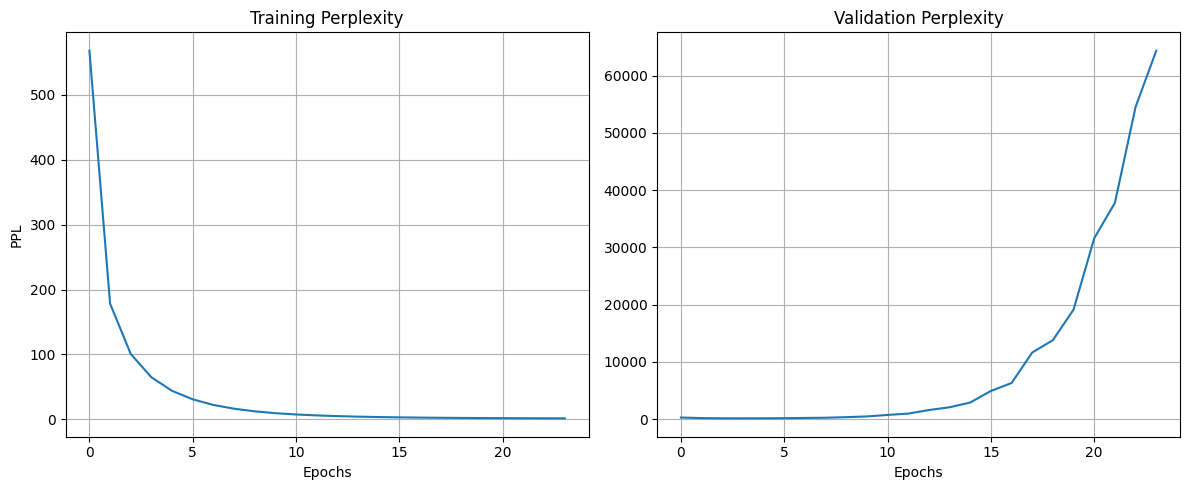

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(train_ppl)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel('PPL')
axes[0].set_title(f"Training Perplexity")
axes[0].grid(True)

axes[1].plot(val_ppl)
axes[1].set_xlabel("Epochs")
axes[1].set_title("Validation Perplexity")
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
print(f'Perplexidade mínima: {min(val_ppl):.2f} - atingida na época {val_ppl.index(min(val_ppl))+1}')

Perplexidade mínima: 138.19 - atingida na época 4


---
### Testes

Função para geração de texto

In [ ]:
def text_generation(_text:str, _model=model, _tokenizer=tokenizer, _max_lenght:int=10, _device=device):
  """
    Gerador de texto
  """

  # modo de inferência
  _model.eval()
  # configuro no dispositivo utilizado
  _model.to(_device)

  # Obtenho tokens codificados e as máscaras de atenção
  out_tokenizer = _tokenizer(_text, return_tensors='pt')
  input_ids = out_tokenizer['input_ids'].to(_device)
  attention_mask = out_tokenizer['attention_mask'].to(_device)

  # obtenho a sentença
  generated = input_ids[0].tolist()

  for _ in range(_max_lenght):
    # contexto (para tensor)
    context_ids = torch.tensor([generated], dtype=torch.long, device=_device)
    # tensor de máscara (como todos os token são válidos, logo, todos os elementos devem ser 1)
    context_masks = torch.ones_like(context_ids, dtype=torch.long, device=_device)

    # desativo cálculo de gradiente
    with torch.no_grad():
      logits = _model(context_ids, context_masks)

    # Sampling com temperatura (tentativa de evitar tokens repetidos - Não funcionou muito bem :/ )
    probs = torch.softmax(logits / 1.2, dim=-1)
    next_token_id = torch.multinomial(probs, num_samples=1).item()

    # Ignoro token [SEP]
    if next_token_id == tokenizer.sep_token_id:
            break

    # add na lista o token gerado
    generated.append(next_token_id)

  # Decodifica para string (ignora tokens especiais)
  text = tokenizer.decode(generated, skip_special_tokens=True)
  return text

In [ ]:
text = "As novas tecnologias "
generated_text = text_generation(text, _max_lenght=30)
print("Texto gerado:", generated_text)

Texto gerado: As novas tecnologias,,,,,,, ou como ou mais um chegado de um de e de de um cinco de um ou cinco e de um de cinco


Com relação à geração de texto notei que meu modelo repete muitos tokens do tipo "pontuação", como ponto final e vírgula. Não removi tais tokens do dataset, pois achei incorreto tal procedimento, porém, não consegui aprimorar o modelo, a ponto de, atingir uma redução significativa de geração de tokens repetidos.